# Lab 00 Solution: Envelope Modulation of Random Signals

This notebook follows the refined guide from `docs/lab00_.pdf` and
preserves the exact stage titles required by the lab:

- Stage 0: Generation of Input Signal
- Stage 1: RC Low-Pass Filtering
- Stage 2: Conventional AM Modulation
- Stage 3: Envelope Detection
- Comparison and Analysis

The implementation uses the same notation from the guide:

- $x[n]$: white Gaussian input
- $x_1[n]$: low-pass message signal
- $x_2[n]$: conventional AM waveform
- $x_{rect}[n]$: rectified waveform
- $x_{env}[n]$: smoothed envelope estimate
- $x_{demod}[n]$: recovered message after DC removal and normalization


## Parameter Selection

The default numerical setup follows the recommended values in the
lab PDF, with validated adjustments:

- $f_n = 10\,\text{Hz}$
- $k = 30$
- $f_0 = k f_n = 300\,\text{Hz}$
- $A_0 = 6.0$
- $f_s = 15{,}000\,\text{Hz}$
- $T = 50\,\text{s}$
- $N = f_s T = 750{,}000$
- $f_{demod} = 300\,\text{Hz}$

The notebook estimates ACFs with an FFT-based unbiased estimator and
PSDs with Welch's method, matching the intent of the guide while
keeping the runtime practical. The increase from $A_0 = 4.0$ to
$A_0 = 6.0$ is deliberate: for a long normalized Gaussian record,
the original suggestion can violate $\mu_{peak} < 1$. The
demodulator bandwidth is also widened to preserve the recovered
envelope while still attenuating the dominant rectifier ripple
around $2f_0 = 600\,\text{Hz}$.


In [1]:
import os
from dataclasses import dataclass

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

plt.style.use("seaborn-v0_8-whitegrid")


@dataclass(frozen=True)
class LabParameters:
    seed: int = 20260420
    f_n_hz: float = 10.0
    carrier_ratio: int = 30
    a0: float = 6.0
    fs_hz: float = 15_000.0
    duration_s: float = 50.0
    f_demod_hz: float = 300.0
    welch_nperseg: int = 16_384
    welch_overlap: int = 8_192
    acf_window_s: float = 0.20
    long_time_window_s: float = 0.50
    short_time_window_s: float = 0.03


params = LabParameters()
rng = np.random.default_rng(params.seed)

f_0_hz = params.carrier_ratio * params.f_n_hz
n_samples = int(params.duration_s * params.fs_hz)
sample_period_s = 1.0 / params.fs_hz
time_s = np.arange(n_samples, dtype=float) * sample_period_s


def design_butter_lowpass(order: int, cutoff_hz: float, fs_hz: float) -> np.ndarray:
    """Returns a stable SOS Butterworth low-pass filter."""
    return signal.butter(order, cutoff_hz, btype="low", fs=fs_hz, output="sos")


def apply_lowpass(
    samples: np.ndarray,
    sos: np.ndarray,
    *,
    zero_phase: bool = False,
) -> np.ndarray:
    """Applies a low-pass filter, optionally with zero-phase smoothing."""
    samples = np.asarray(samples, dtype=float)
    if zero_phase:
        return signal.sosfiltfilt(sos, samples)
    return signal.sosfilt(sos, samples)


def estimate_unbiased_acf(
    samples: np.ndarray,
    fs_hz: float,
    max_lag_s: float,
) -> tuple[np.ndarray, np.ndarray]:
    """Computes the mean-removed unbiased sample ACF on symmetric lags."""
    centered = np.asarray(samples, dtype=float) - np.mean(samples)
    n = centered.size
    max_lag = int(max_lag_s * fs_hz)
    n_fft = 1 << (2 * n - 1).bit_length()
    spectrum = np.fft.rfft(centered, n=n_fft)
    corr = np.fft.irfft(spectrum * np.conjugate(spectrum), n=n_fft)[: max_lag + 1]
    normalization = n - np.arange(max_lag + 1)
    acf_nonnegative = corr / normalization
    lags_nonnegative_s = np.arange(max_lag + 1) / fs_hz
    if max_lag == 0:
        return lags_nonnegative_s, acf_nonnegative
    lags_s = np.concatenate((-lags_nonnegative_s[:0:-1], lags_nonnegative_s))
    acf = np.concatenate((acf_nonnegative[:0:-1], acf_nonnegative))
    return lags_s, acf


def estimate_centered_welch_psd(
    samples: np.ndarray,
    fs_hz: float,
    nperseg: int,
    noverlap: int,
) -> tuple[np.ndarray, np.ndarray]:
    """Returns a centered, two-sided Welch PSD estimate."""
    centered = np.asarray(samples, dtype=float) - np.mean(samples)
    segment_length = min(nperseg, centered.size)
    overlap = min(noverlap, segment_length // 2)
    freqs_hz, psd = signal.welch(
        centered,
        fs=fs_hz,
        window="hann",
        nperseg=segment_length,
        noverlap=overlap,
        detrend=False,
        return_onesided=False,
        scaling="density",
    )
    return np.fft.fftshift(freqs_hz), np.fft.fftshift(psd)


def corrcoef_safe(x: np.ndarray, y: np.ndarray) -> float:
    """Returns Pearson correlation while guarding against zero-variance input."""
    x_std = float(np.std(x))
    y_std = float(np.std(y))
    if x_std == 0.0 or y_std == 0.0:
        return float("nan")
    return float(np.corrcoef(x, y)[0, 1])


stage1_sos = design_butter_lowpass(order=1, cutoff_hz=params.f_n_hz, fs_hz=params.fs_hz)
stage3_sos = design_butter_lowpass(order=4, cutoff_hz=params.f_demod_hz, fs_hz=params.fs_hz)

print("seed =", params.seed)
print(f"f_n = {params.f_n_hz:.1f} Hz")
print("k =", params.carrier_ratio)
print(f"f_0 = {f_0_hz:.1f} Hz")
print(f"A_0 = {params.a0:.2f}")
print(f"f_s = {params.fs_hz:.1f} Hz")
print(f"T = {params.duration_s:.1f} s")
print("N =", n_samples)
print(f"f_demod = {params.f_demod_hz:.1f} Hz")


seed = 20260420
f_n = 10.0 Hz
k = 30
f_0 = 300.0 Hz
A_0 = 6.00
f_s = 15000.0 Hz
T = 50.0 s
N = 750000
f_demod = 300.0 Hz


## Stage 0: Generation of Input Signal

Generate the discrete-time white Gaussian noise realization

$$
x[n] \sim \mathcal{N}(0, 1),
$$

then estimate its sample ACF $R_{xx}[\ell]$ and PSD $S_{xx}(f)$.


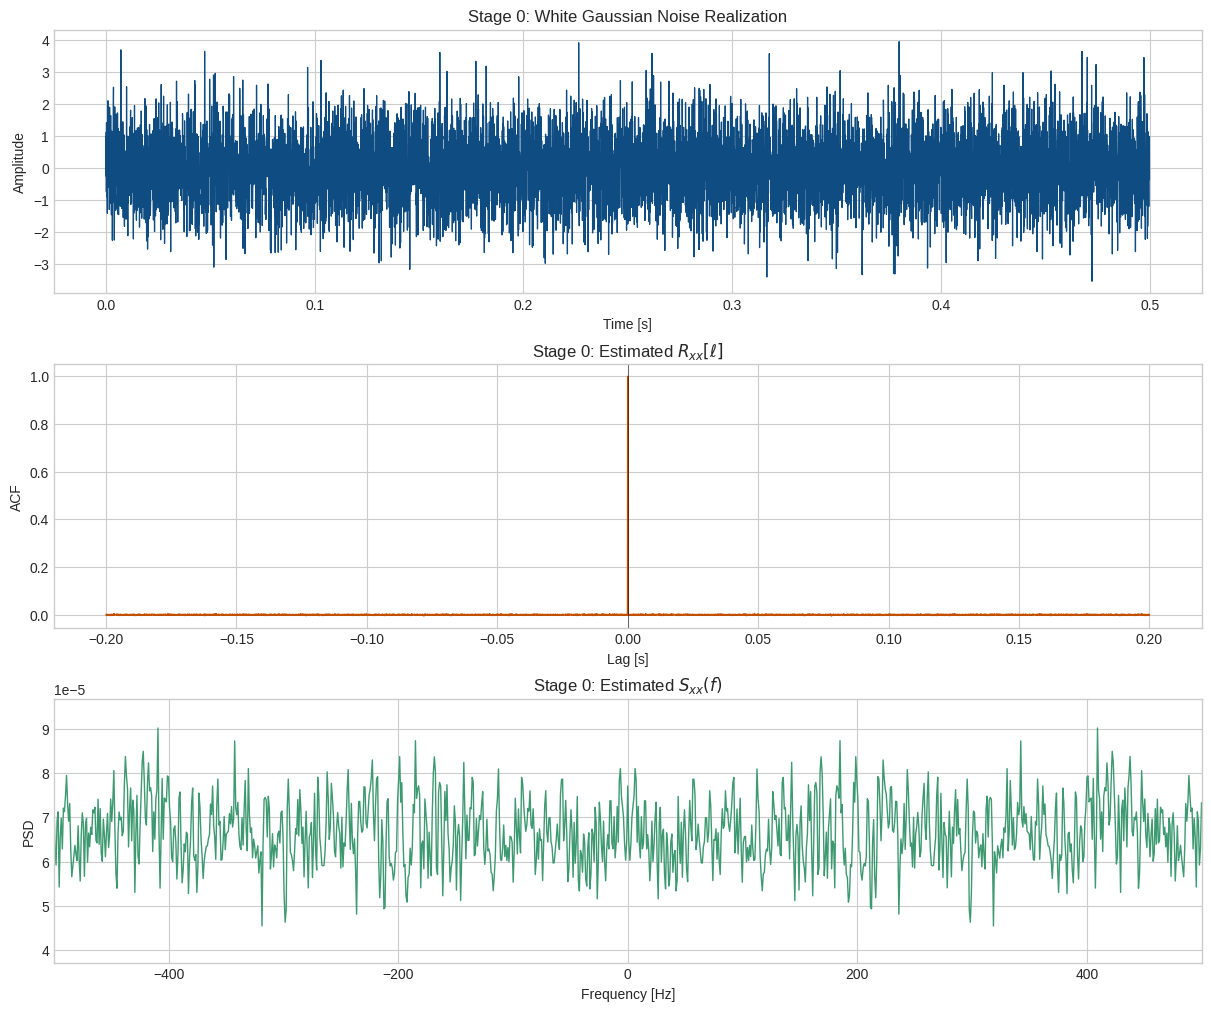

mean(x[n]) = +2.0882e-04
var(x[n])  = 0.9990


In [2]:
x = rng.normal(loc=0.0, scale=1.0, size=n_samples)

lags_x_s, acf_x = estimate_unbiased_acf(
    x,
    fs_hz=params.fs_hz,
    max_lag_s=params.acf_window_s,
)
freqs_x_hz, psd_x = estimate_centered_welch_psd(
    x,
    fs_hz=params.fs_hz,
    nperseg=params.welch_nperseg,
    noverlap=params.welch_overlap,
)

stage0_window = int(params.long_time_window_s * params.fs_hz)
fig, axes = plt.subplots(3, 1, figsize=(12, 10), constrained_layout=True)

axes[0].plot(time_s[:stage0_window], x[:stage0_window], linewidth=0.9, color="#0f4c81")
axes[0].set_title("Stage 0: White Gaussian Noise Realization")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Amplitude")

axes[1].plot(lags_x_s, acf_x, linewidth=1.1, color="#c24e00")
axes[1].axvline(0.0, color="black", linewidth=0.7, alpha=0.5)
axes[1].set_title(r"Stage 0: Estimated $R_{xx}[\ell]$")
axes[1].set_xlabel("Lag [s]")
axes[1].set_ylabel("ACF")

axes[2].plot(freqs_x_hz, psd_x, linewidth=1.0, color="#3d9970")
axes[2].set_xlim(-500.0, 500.0)
axes[2].set_title(r"Stage 0: Estimated $S_{xx}(f)$")
axes[2].set_xlabel("Frequency [Hz]")
axes[2].set_ylabel("PSD")

plt.show()

print(f"mean(x[n]) = {np.mean(x):+.4e}")
print(f"var(x[n])  = {np.var(x):.4f}")


## Stage 1: RC Low-Pass Filtering

Filter the white-noise input with a first-order low-pass stage to
obtain the message signal $x_1[n]$, then normalize it to unit
variance so the modulation index is controlled by $A_0$.

The lab PDF compares this stage against the continuous-time RC
shapes

$$
R_{x_1x_1}(\tau) \propto e^{-2\pi f_n |\tau|},
\qquad
S_{x_1x_1}(f) \propto \frac{1}{1 + (f/f_n)^2}.
$$


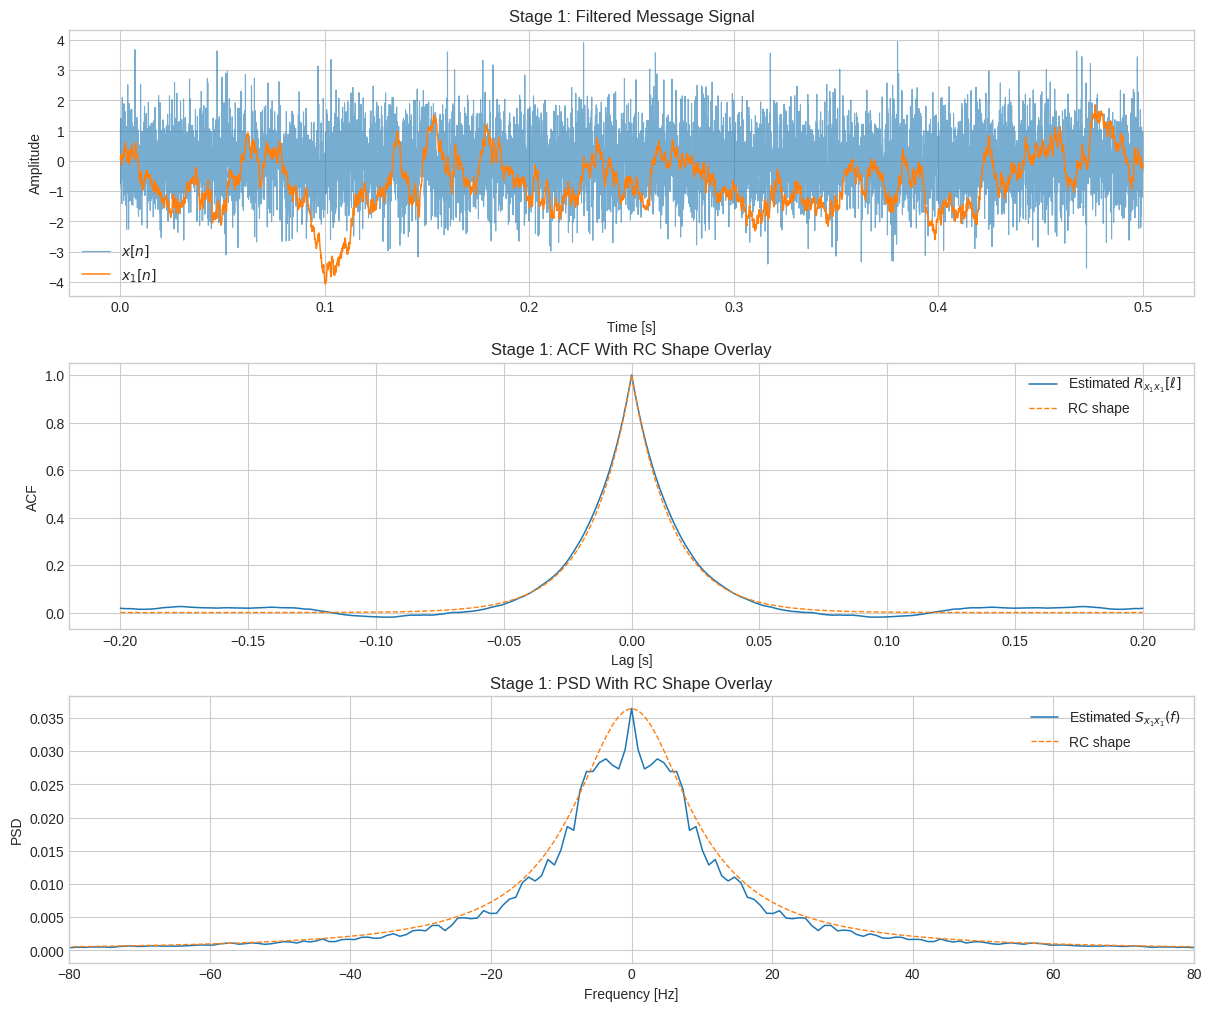

mean(x_1[n]) = +9.7013e-18
std(x_1[n])  = 1.0000


In [3]:
x_1_raw = apply_lowpass(x, stage1_sos)
x_1_centered = x_1_raw - np.mean(x_1_raw)
x_1 = x_1_centered / np.std(x_1_centered)

lags_x1_s, acf_x1 = estimate_unbiased_acf(
    x_1,
    fs_hz=params.fs_hz,
    max_lag_s=params.acf_window_s,
)
freqs_x1_hz, psd_x1 = estimate_centered_welch_psd(
    x_1,
    fs_hz=params.fs_hz,
    nperseg=params.welch_nperseg,
    noverlap=params.welch_overlap,
)

acf_shape = np.exp(-2.0 * np.pi * params.f_n_hz * np.abs(lags_x1_s))
psd_shape = 1.0 / (1.0 + (freqs_x1_hz / params.f_n_hz) ** 2)
psd_shape *= np.max(psd_x1) / np.max(psd_shape)

stage1_window = int(params.long_time_window_s * params.fs_hz)
fig, axes = plt.subplots(3, 1, figsize=(12, 10), constrained_layout=True)

axes[0].plot(time_s[:stage1_window], x[:stage1_window], label=r"$x[n]$", linewidth=0.8, alpha=0.6)
axes[0].plot(time_s[:stage1_window], x_1[:stage1_window], label=r"$x_1[n]$", linewidth=1.1)
axes[0].set_title("Stage 1: Filtered Message Signal")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Amplitude")
axes[0].legend()

axes[1].plot(lags_x1_s, acf_x1, label=r"Estimated $R_{x_1x_1}[\ell]$", linewidth=1.1)
axes[1].plot(lags_x1_s, acf_shape, label="RC shape", linestyle="--", linewidth=1.0)
axes[1].set_title("Stage 1: ACF With RC Shape Overlay")
axes[1].set_xlabel("Lag [s]")
axes[1].set_ylabel("ACF")
axes[1].legend()

axes[2].plot(freqs_x1_hz, psd_x1, label=r"Estimated $S_{x_1x_1}(f)$", linewidth=1.1)
axes[2].plot(freqs_x1_hz, psd_shape, label="RC shape", linestyle="--", linewidth=1.0)
axes[2].set_xlim(-80.0, 80.0)
axes[2].set_title("Stage 1: PSD With RC Shape Overlay")
axes[2].set_xlabel("Frequency [Hz]")
axes[2].set_ylabel("PSD")
axes[2].legend()

plt.show()

print(f"mean(x_1[n]) = {np.mean(x_1):+.4e}")
print(f"std(x_1[n])  = {np.std(x_1):.4f}")


## Stage 2: Conventional AM Modulation

Form the conventional AM waveform

$$
x_2[n] = (A_0 + x_1[n])\cos(2\pi f_0 n T_s),
$$

and verify the modulation conditions

$$
\mu_{peak} = \frac{\max_n |x_1[n]|}{A_0} < 1,
\qquad
\mu_{rms} = \frac{\sigma_{x_1}}{A_0}.
$$


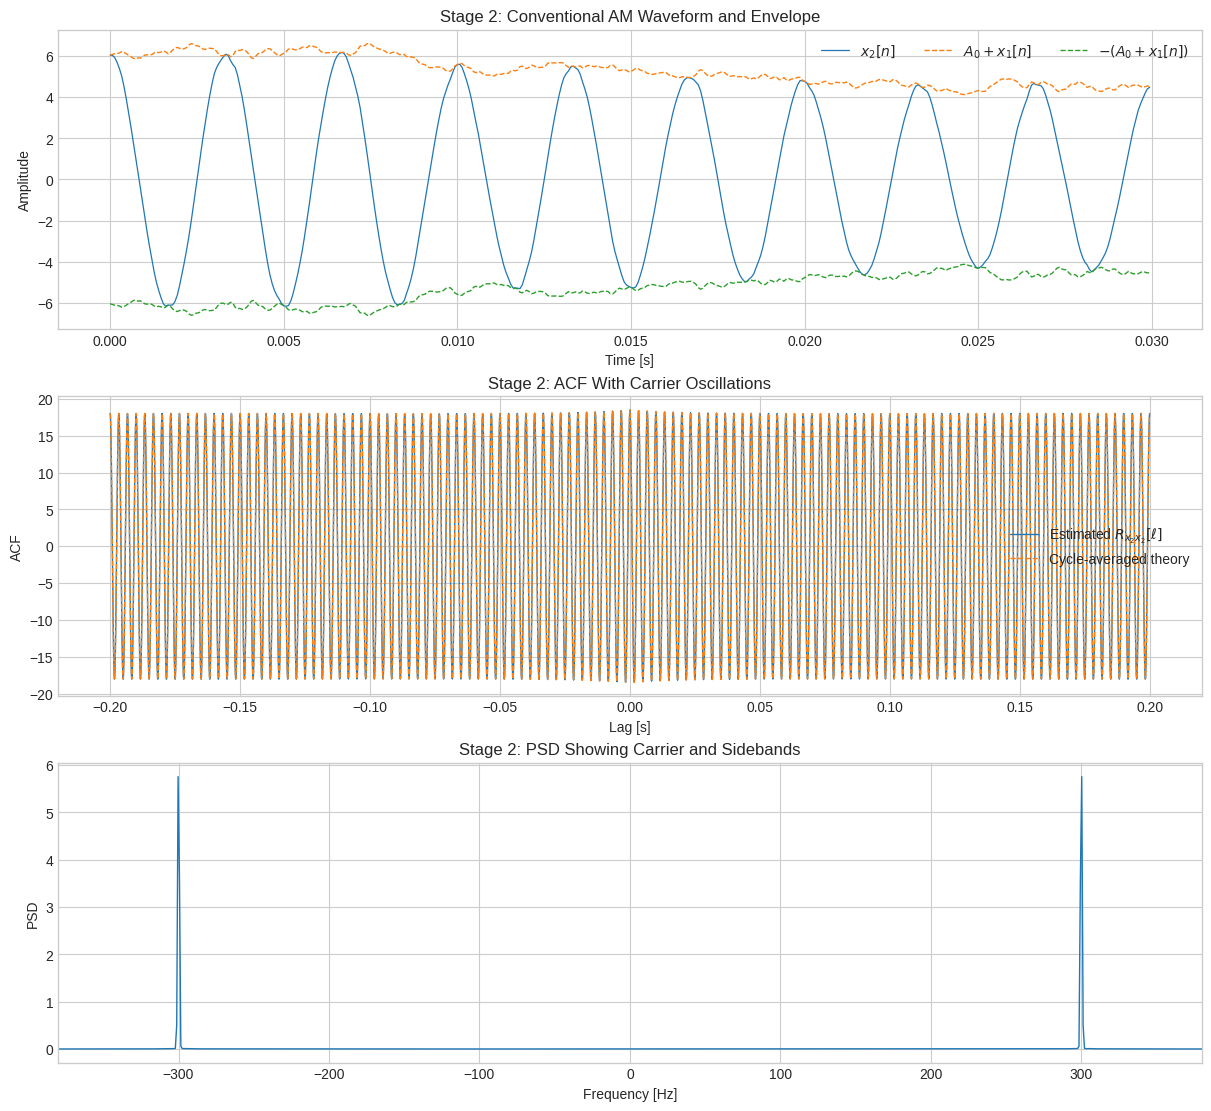

mu_peak = 0.6812
mu_rms = 0.1667
min(A_0 + x_1[n]) = 1.9128
power efficiency = 2.70%


In [4]:
carrier = np.cos(2.0 * np.pi * f_0_hz * time_s)
envelope = params.a0 + x_1
x_2 = envelope * carrier

mu_peak = float(np.max(np.abs(x_1)) / params.a0)
mu_rms = float(np.std(x_1) / params.a0)
min_envelope = float(np.min(envelope))
power_efficiency_pct = 100.0 * (mu_rms ** 2) / (1.0 + mu_rms ** 2)

lags_x2_s, acf_x2 = estimate_unbiased_acf(
    x_2,
    fs_hz=params.fs_hz,
    max_lag_s=params.acf_window_s,
)
freqs_x2_hz, psd_x2 = estimate_centered_welch_psd(
    x_2,
    fs_hz=params.fs_hz,
    nperseg=params.welch_nperseg,
    noverlap=params.welch_overlap,
)

acf_x1_nonnegative = acf_x1[lags_x1_s >= 0.0]
lags_x1_nonnegative = lags_x1_s[lags_x1_s >= 0.0]
acf_x2_theoretical_nonnegative = 0.5 * (
    params.a0 ** 2 + acf_x1_nonnegative
) * np.cos(2.0 * np.pi * f_0_hz * lags_x1_nonnegative)
acf_x2_theoretical = np.concatenate(
    (
        acf_x2_theoretical_nonnegative[:0:-1],
        acf_x2_theoretical_nonnegative,
    )
)

stage2_short = int(params.short_time_window_s * params.fs_hz)
stage2_long = int(params.long_time_window_s * params.fs_hz)
fig, axes = plt.subplots(3, 1, figsize=(12, 11), constrained_layout=True)

axes[0].plot(time_s[:stage2_short], x_2[:stage2_short], linewidth=0.9, label=r"$x_2[n]$")
axes[0].plot(time_s[:stage2_short], envelope[:stage2_short], linestyle="--", linewidth=1.0, label=r"$A_0 + x_1[n]$")
axes[0].plot(time_s[:stage2_short], -envelope[:stage2_short], linestyle="--", linewidth=1.0, label=r"$-(A_0 + x_1[n])$")
axes[0].set_title("Stage 2: Conventional AM Waveform and Envelope")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Amplitude")
axes[0].legend(loc="upper right", ncol=3)

axes[1].plot(lags_x2_s, acf_x2, label=r"Estimated $R_{x_2x_2}[\ell]$", linewidth=1.0)
axes[1].plot(lags_x2_s, acf_x2_theoretical, linestyle="--", label="Cycle-averaged theory", linewidth=1.0)
axes[1].set_title("Stage 2: ACF With Carrier Oscillations")
axes[1].set_xlabel("Lag [s]")
axes[1].set_ylabel("ACF")
axes[1].legend()

axes[2].plot(freqs_x2_hz, psd_x2, linewidth=1.0)
axes[2].set_xlim(-(f_0_hz + 80.0), f_0_hz + 80.0)
axes[2].set_title("Stage 2: PSD Showing Carrier and Sidebands")
axes[2].set_xlabel("Frequency [Hz]")
axes[2].set_ylabel("PSD")

plt.show()

print(f"mu_peak = {mu_peak:.4f}")
print(f"mu_rms = {mu_rms:.4f}")
print(f"min(A_0 + x_1[n]) = {min_envelope:.4f}")
print(f"power efficiency = {power_efficiency_pct:.2f}%")


## Stage 3: Envelope Detection

Follow the lab's nonlinear detector:

1. Rectify: $x_{rect}[n] = |x_2[n]|$
2. Low-pass filter the rectified signal to obtain $x_{env}[n]$
3. Remove the DC component
4. Normalize the result so it can be compared against $x_1[n]$

The recovered signal is denoted by $x_{demod}[n]$.


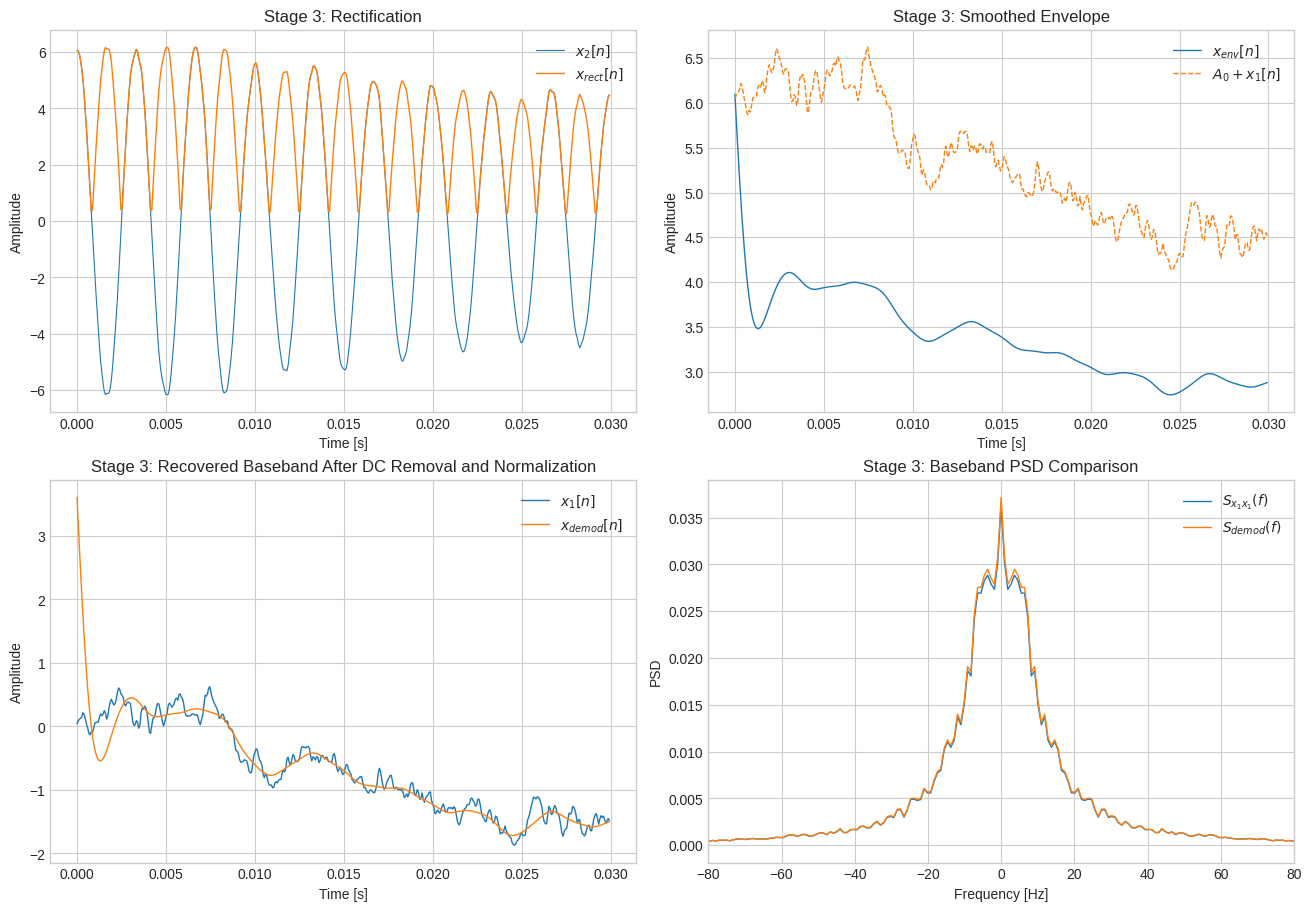

rho(x_1, x_demod) = 0.9907
NMSE = 0.018540
SNR  = 17.32 dB


In [5]:
x_rect = np.abs(x_2)
x_env = apply_lowpass(x_rect, stage3_sos, zero_phase=True)
x_demod_dc_removed = x_env - np.mean(x_env)
x_demod = x_demod_dc_removed * (np.std(x_1) / np.std(x_demod_dc_removed))

lags_demod_s, acf_demod = estimate_unbiased_acf(
    x_demod,
    fs_hz=params.fs_hz,
    max_lag_s=params.acf_window_s,
)
freqs_demod_hz, psd_demod = estimate_centered_welch_psd(
    x_demod,
    fs_hz=params.fs_hz,
    nperseg=params.welch_nperseg,
    noverlap=params.welch_overlap,
)

rho = corrcoef_safe(x_1, x_demod)
nmse = float(np.mean((x_1 - x_demod) ** 2) / np.var(x_1))
snr_db = float(-10.0 * np.log10(max(nmse, 1e-18)))

stage3_short = int(params.short_time_window_s * params.fs_hz)
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)

axes[0, 0].plot(time_s[:stage3_short], x_2[:stage3_short], linewidth=0.8, label=r"$x_2[n]$")
axes[0, 0].plot(time_s[:stage3_short], x_rect[:stage3_short], linewidth=1.0, label=r"$x_{rect}[n]$")
axes[0, 0].set_title("Stage 3: Rectification")
axes[0, 0].set_xlabel("Time [s]")
axes[0, 0].set_ylabel("Amplitude")
axes[0, 0].legend()

axes[0, 1].plot(time_s[:stage3_short], x_env[:stage3_short], linewidth=1.0, label=r"$x_{env}[n]$")
axes[0, 1].plot(time_s[:stage3_short], params.a0 + x_1[:stage3_short], linestyle="--", linewidth=1.0, label=r"$A_0 + x_1[n]$")
axes[0, 1].set_title("Stage 3: Smoothed Envelope")
axes[0, 1].set_xlabel("Time [s]")
axes[0, 1].set_ylabel("Amplitude")
axes[0, 1].legend()

axes[1, 0].plot(time_s[:stage3_short], x_1[:stage3_short], linewidth=1.0, label=r"$x_1[n]$")
axes[1, 0].plot(time_s[:stage3_short], x_demod[:stage3_short], linewidth=1.0, label=r"$x_{demod}[n]$")
axes[1, 0].set_title("Stage 3: Recovered Baseband After DC Removal and Normalization")
axes[1, 0].set_xlabel("Time [s]")
axes[1, 0].set_ylabel("Amplitude")
axes[1, 0].legend()

axes[1, 1].plot(freqs_x1_hz, psd_x1, linewidth=1.0, label=r"$S_{x_1x_1}(f)$")
axes[1, 1].plot(freqs_demod_hz, psd_demod, linewidth=1.0, label=r"$S_{demod}(f)$")
axes[1, 1].set_xlim(-80.0, 80.0)
axes[1, 1].set_title("Stage 3: Baseband PSD Comparison")
axes[1, 1].set_xlabel("Frequency [Hz]")
axes[1, 1].set_ylabel("PSD")
axes[1, 1].legend()

plt.show()

print(f"rho(x_1, x_demod) = {rho:.4f}")
print(f"NMSE = {nmse:.6f}")
print(f"SNR  = {snr_db:.2f} dB")


## Comparison and Analysis

The remaining figures align with the deliverables listed in the lab
PDF:

- modulation-index analysis
- error analysis
- comprehensive time/frequency comparison


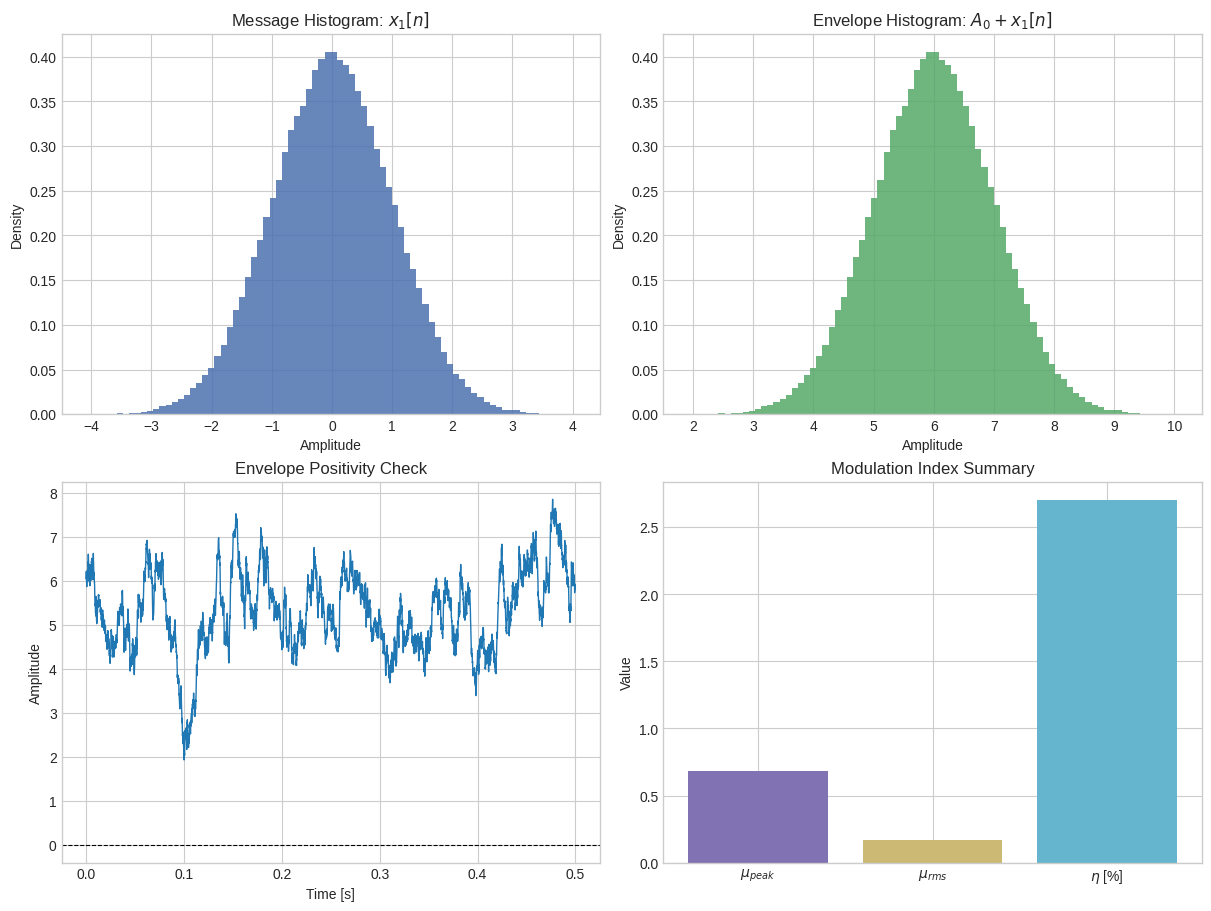

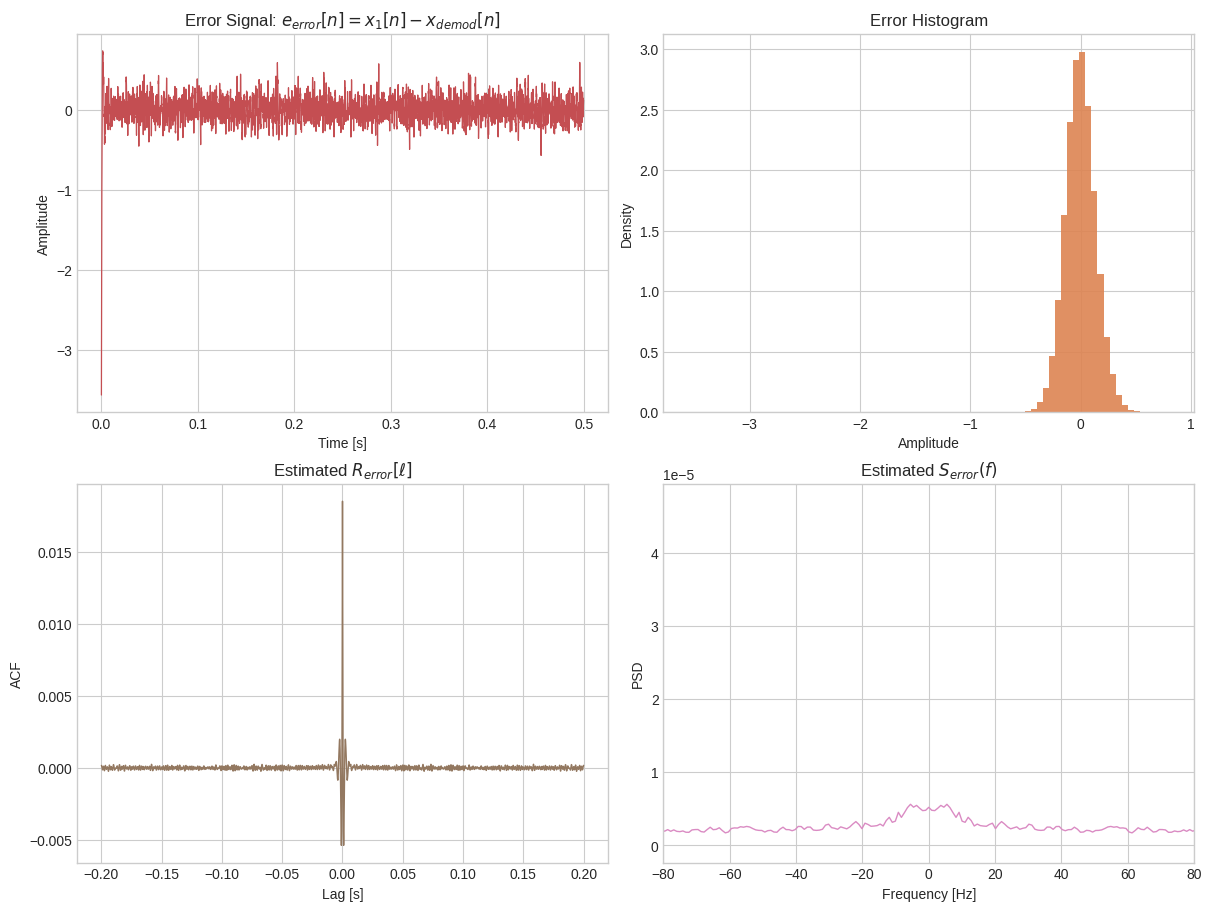

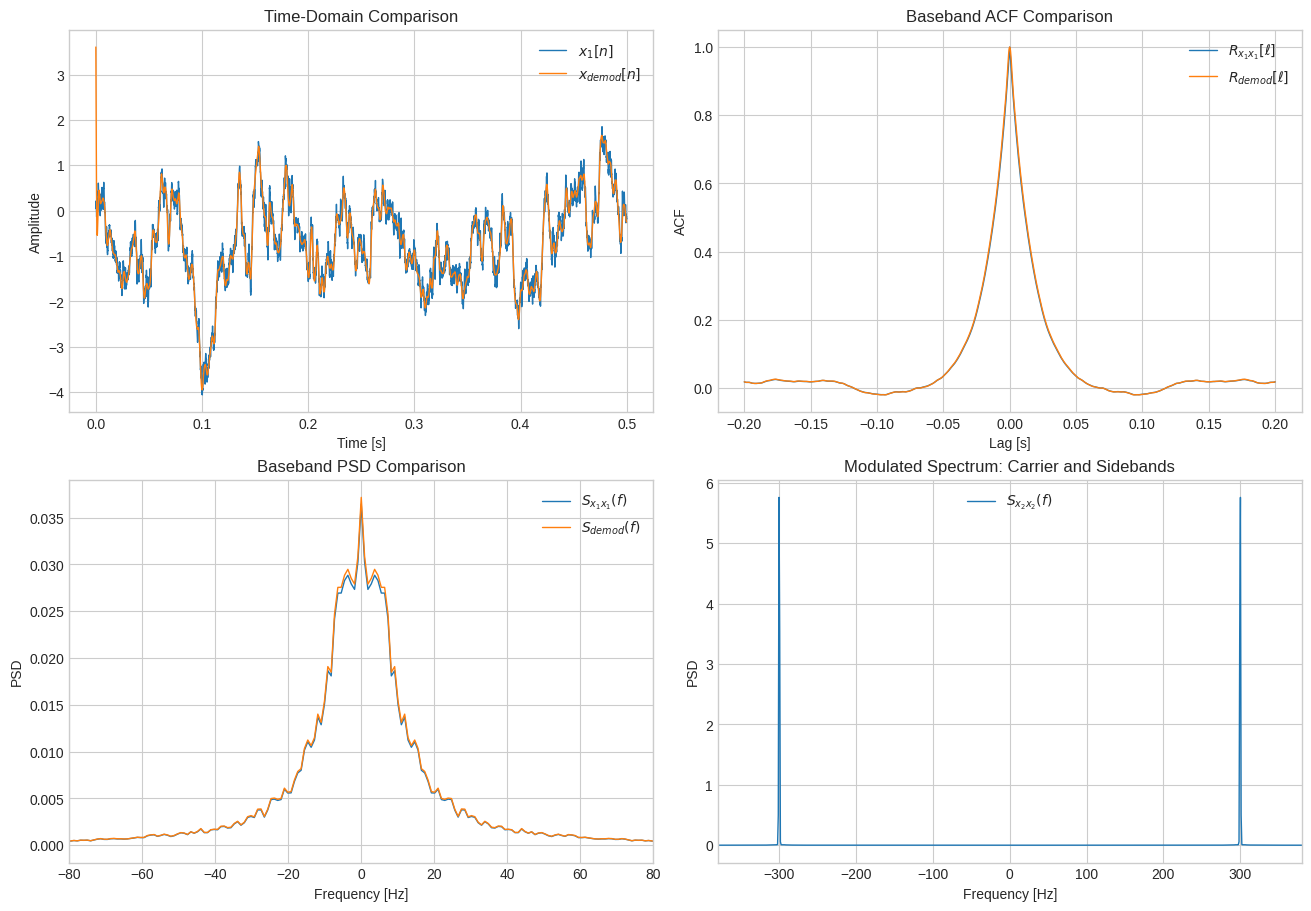

Summary metrics
----------------
mu_peak            = 0.6812
mu_rms             = 0.1667
min envelope       = 1.9128
rho                = 0.9907
NMSE               = 0.018540
SNR [dB]           = 17.32
power efficiency   = 2.70%
error mean         = -3.3610e-16
error std          = 0.1362
error max abs      = 3.5622
occupied bandwidth = approximately 2 f_n = 20 Hz


In [6]:
e_error = x_1 - x_demod
lags_error_s, acf_error = estimate_unbiased_acf(
    e_error,
    fs_hz=params.fs_hz,
    max_lag_s=params.acf_window_s,
)
freqs_error_hz, psd_error = estimate_centered_welch_psd(
    e_error,
    fs_hz=params.fs_hz,
    nperseg=params.welch_nperseg,
    noverlap=params.welch_overlap,
)

hist_window = int(params.long_time_window_s * params.fs_hz)

fig_mod, axes_mod = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
axes_mod[0, 0].hist(x_1, bins=80, density=True, color="#4c72b0", alpha=0.85)
axes_mod[0, 0].set_title(r"Message Histogram: $x_1[n]$")
axes_mod[0, 0].set_xlabel("Amplitude")
axes_mod[0, 0].set_ylabel("Density")

axes_mod[0, 1].hist(envelope, bins=80, density=True, color="#55a868", alpha=0.85)
axes_mod[0, 1].set_title(r"Envelope Histogram: $A_0 + x_1[n]$")
axes_mod[0, 1].set_xlabel("Amplitude")
axes_mod[0, 1].set_ylabel("Density")

axes_mod[1, 0].plot(time_s[:hist_window], envelope[:hist_window], linewidth=1.0)
axes_mod[1, 0].axhline(0.0, color="black", linewidth=0.8, linestyle="--")
axes_mod[1, 0].set_title("Envelope Positivity Check")
axes_mod[1, 0].set_xlabel("Time [s]")
axes_mod[1, 0].set_ylabel("Amplitude")

axes_mod[1, 1].bar(
    [r"$\mu_{peak}$", r"$\mu_{rms}$", r"$\eta$ [%]"],
    [mu_peak, mu_rms, power_efficiency_pct],
    color=["#8172b3", "#ccb974", "#64b5cd"],
)
axes_mod[1, 1].set_title("Modulation Index Summary")
axes_mod[1, 1].set_ylabel("Value")

plt.show()

fig_err, axes_err = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
axes_err[0, 0].plot(time_s[:hist_window], e_error[:hist_window], linewidth=0.9, color="#c44e52")
axes_err[0, 0].set_title(r"Error Signal: $e_{error}[n] = x_1[n] - x_{demod}[n]$")
axes_err[0, 0].set_xlabel("Time [s]")
axes_err[0, 0].set_ylabel("Amplitude")

axes_err[0, 1].hist(e_error, bins=80, density=True, color="#dd8452", alpha=0.9)
axes_err[0, 1].set_title("Error Histogram")
axes_err[0, 1].set_xlabel("Amplitude")
axes_err[0, 1].set_ylabel("Density")

axes_err[1, 0].plot(lags_error_s, acf_error, linewidth=1.0, color="#937860")
axes_err[1, 0].set_title(r"Estimated $R_{error}[\ell]$")
axes_err[1, 0].set_xlabel("Lag [s]")
axes_err[1, 0].set_ylabel("ACF")

axes_err[1, 1].plot(freqs_error_hz, psd_error, linewidth=1.0, color="#da8bc3")
axes_err[1, 1].set_xlim(-80.0, 80.0)
axes_err[1, 1].set_title(r"Estimated $S_{error}(f)$")
axes_err[1, 1].set_xlabel("Frequency [Hz]")
axes_err[1, 1].set_ylabel("PSD")

plt.show()

fig_cmp, axes_cmp = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
compare_window = int(params.long_time_window_s * params.fs_hz)
axes_cmp[0, 0].plot(time_s[:compare_window], x_1[:compare_window], linewidth=1.0, label=r"$x_1[n]$")
axes_cmp[0, 0].plot(time_s[:compare_window], x_demod[:compare_window], linewidth=1.0, label=r"$x_{demod}[n]$")
axes_cmp[0, 0].set_title("Time-Domain Comparison")
axes_cmp[0, 0].set_xlabel("Time [s]")
axes_cmp[0, 0].set_ylabel("Amplitude")
axes_cmp[0, 0].legend()

axes_cmp[0, 1].plot(lags_x1_s, acf_x1, linewidth=1.0, label=r"$R_{x_1x_1}[\ell]$")
axes_cmp[0, 1].plot(lags_demod_s, acf_demod, linewidth=1.0, label=r"$R_{demod}[\ell]$")
axes_cmp[0, 1].set_title("Baseband ACF Comparison")
axes_cmp[0, 1].set_xlabel("Lag [s]")
axes_cmp[0, 1].set_ylabel("ACF")
axes_cmp[0, 1].legend()

axes_cmp[1, 0].plot(freqs_x1_hz, psd_x1, linewidth=1.0, label=r"$S_{x_1x_1}(f)$")
axes_cmp[1, 0].plot(freqs_demod_hz, psd_demod, linewidth=1.0, label=r"$S_{demod}(f)$")
axes_cmp[1, 0].set_xlim(-80.0, 80.0)
axes_cmp[1, 0].set_title("Baseband PSD Comparison")
axes_cmp[1, 0].set_xlabel("Frequency [Hz]")
axes_cmp[1, 0].set_ylabel("PSD")
axes_cmp[1, 0].legend()

axes_cmp[1, 1].plot(freqs_x2_hz, psd_x2, linewidth=1.0, label=r"$S_{x_2x_2}(f)$")
axes_cmp[1, 1].set_xlim(-(f_0_hz + 80.0), f_0_hz + 80.0)
axes_cmp[1, 1].set_title("Modulated Spectrum: Carrier and Sidebands")
axes_cmp[1, 1].set_xlabel("Frequency [Hz]")
axes_cmp[1, 1].set_ylabel("PSD")
axes_cmp[1, 1].legend()

plt.show()

print("Summary metrics")
print("----------------")
print(f"mu_peak            = {mu_peak:.4f}")
print(f"mu_rms             = {mu_rms:.4f}")
print(f"min envelope       = {min_envelope:.4f}")
print(f"rho                = {rho:.4f}")
print(f"NMSE               = {nmse:.6f}")
print(f"SNR [dB]           = {snr_db:.2f}")
print(f"power efficiency   = {power_efficiency_pct:.2f}%")
print(f"error mean         = {np.mean(e_error):+.4e}")
print(f"error std          = {np.std(e_error):.4f}")
print(f"error max abs      = {np.max(np.abs(e_error)):.4f}")
print("occupied bandwidth = approximately 2 f_n = 20 Hz")
